# Practice Resolution - Mapping and Monitoring Floods

Download the data for the flood that happened in England and recreate the above maps.

In [1]:
# %%capture
# !pip install rasterio folium matplotlib mapclassify rasterstats

In [2]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterstats import zonal_stats
import folium
from folium.raster_layers import ImageOverlay

## Flood map

In [3]:
h17v03 = rasterio.open('MCDWD_L3_F2_NRT.A2025010.h17v03.061.tif')

In [4]:
h17v03.width, h17v03.height

(4800, 4800)

In [5]:
h17v03.crs

CRS.from_wkt('GEOGCS["Unknown datum based upon the Clarke 1866 ellipsoid",DATUM["Not specified (based on Clarke 1866 spheroid)",SPHEROID["Clarke 1866",6378206.4,294.978698213898,AUTHORITY["EPSG","7008"]]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]')

In [6]:
bounds = h17v03.bounds
bounds = [[bounds.bottom, bounds.left], [bounds.top, bounds.right]]

In [7]:
data_h17v03 = h17v03.read(1)

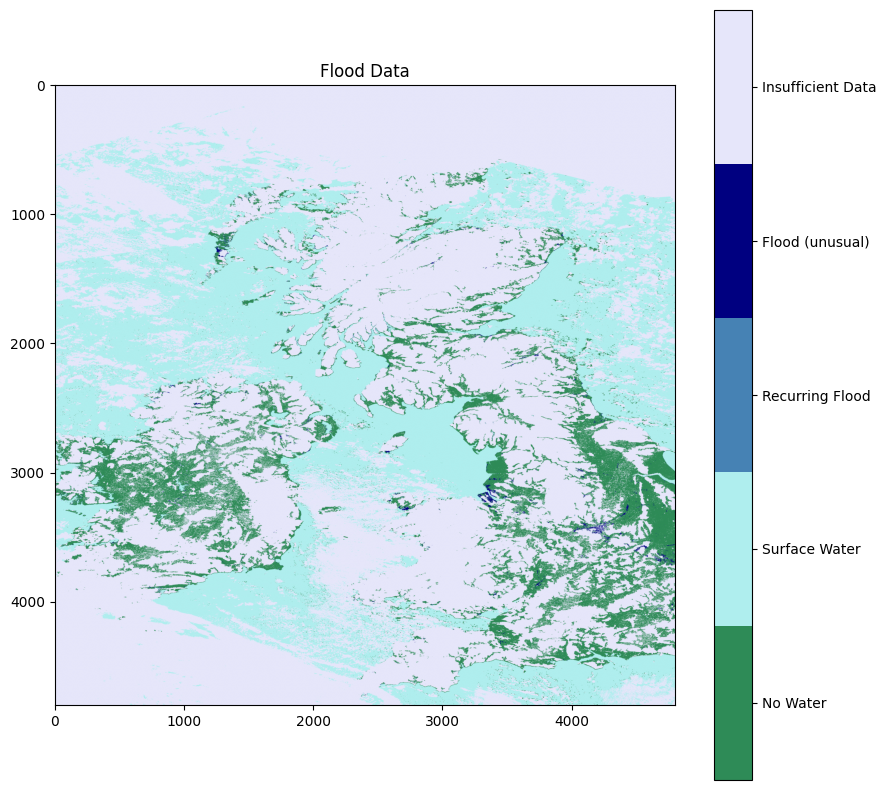

In [8]:
colors = ['seagreen', 'paleturquoise', 'steelblue', 'navy','lavender']
plot_data = data_h17v03.copy()
plot_data[plot_data == 255] = 4 # map 255 to 4 so it looks neat
# Create custom colormap
cmap = ListedColormap(colors)
# Create the plot
plt.figure(figsize=(10, 10))
im = plt.imshow(plot_data, cmap=cmap, vmin=0, vmax=4)

# Create custom colorbar
cbar = plt.colorbar(im, ticks=[0.4, 1.2, 2, 2.8, 3.6])
cbar.ax.set_yticklabels(['No Water', 'Surface Water', 'Recurring Flood', 'Flood (unusual)', 'Insufficient Data'])  # Replace 4 with 255

plt.title('Flood Data')

plt.show()

## Dynamic map

In [10]:
center = [52.525904, -1.826996]


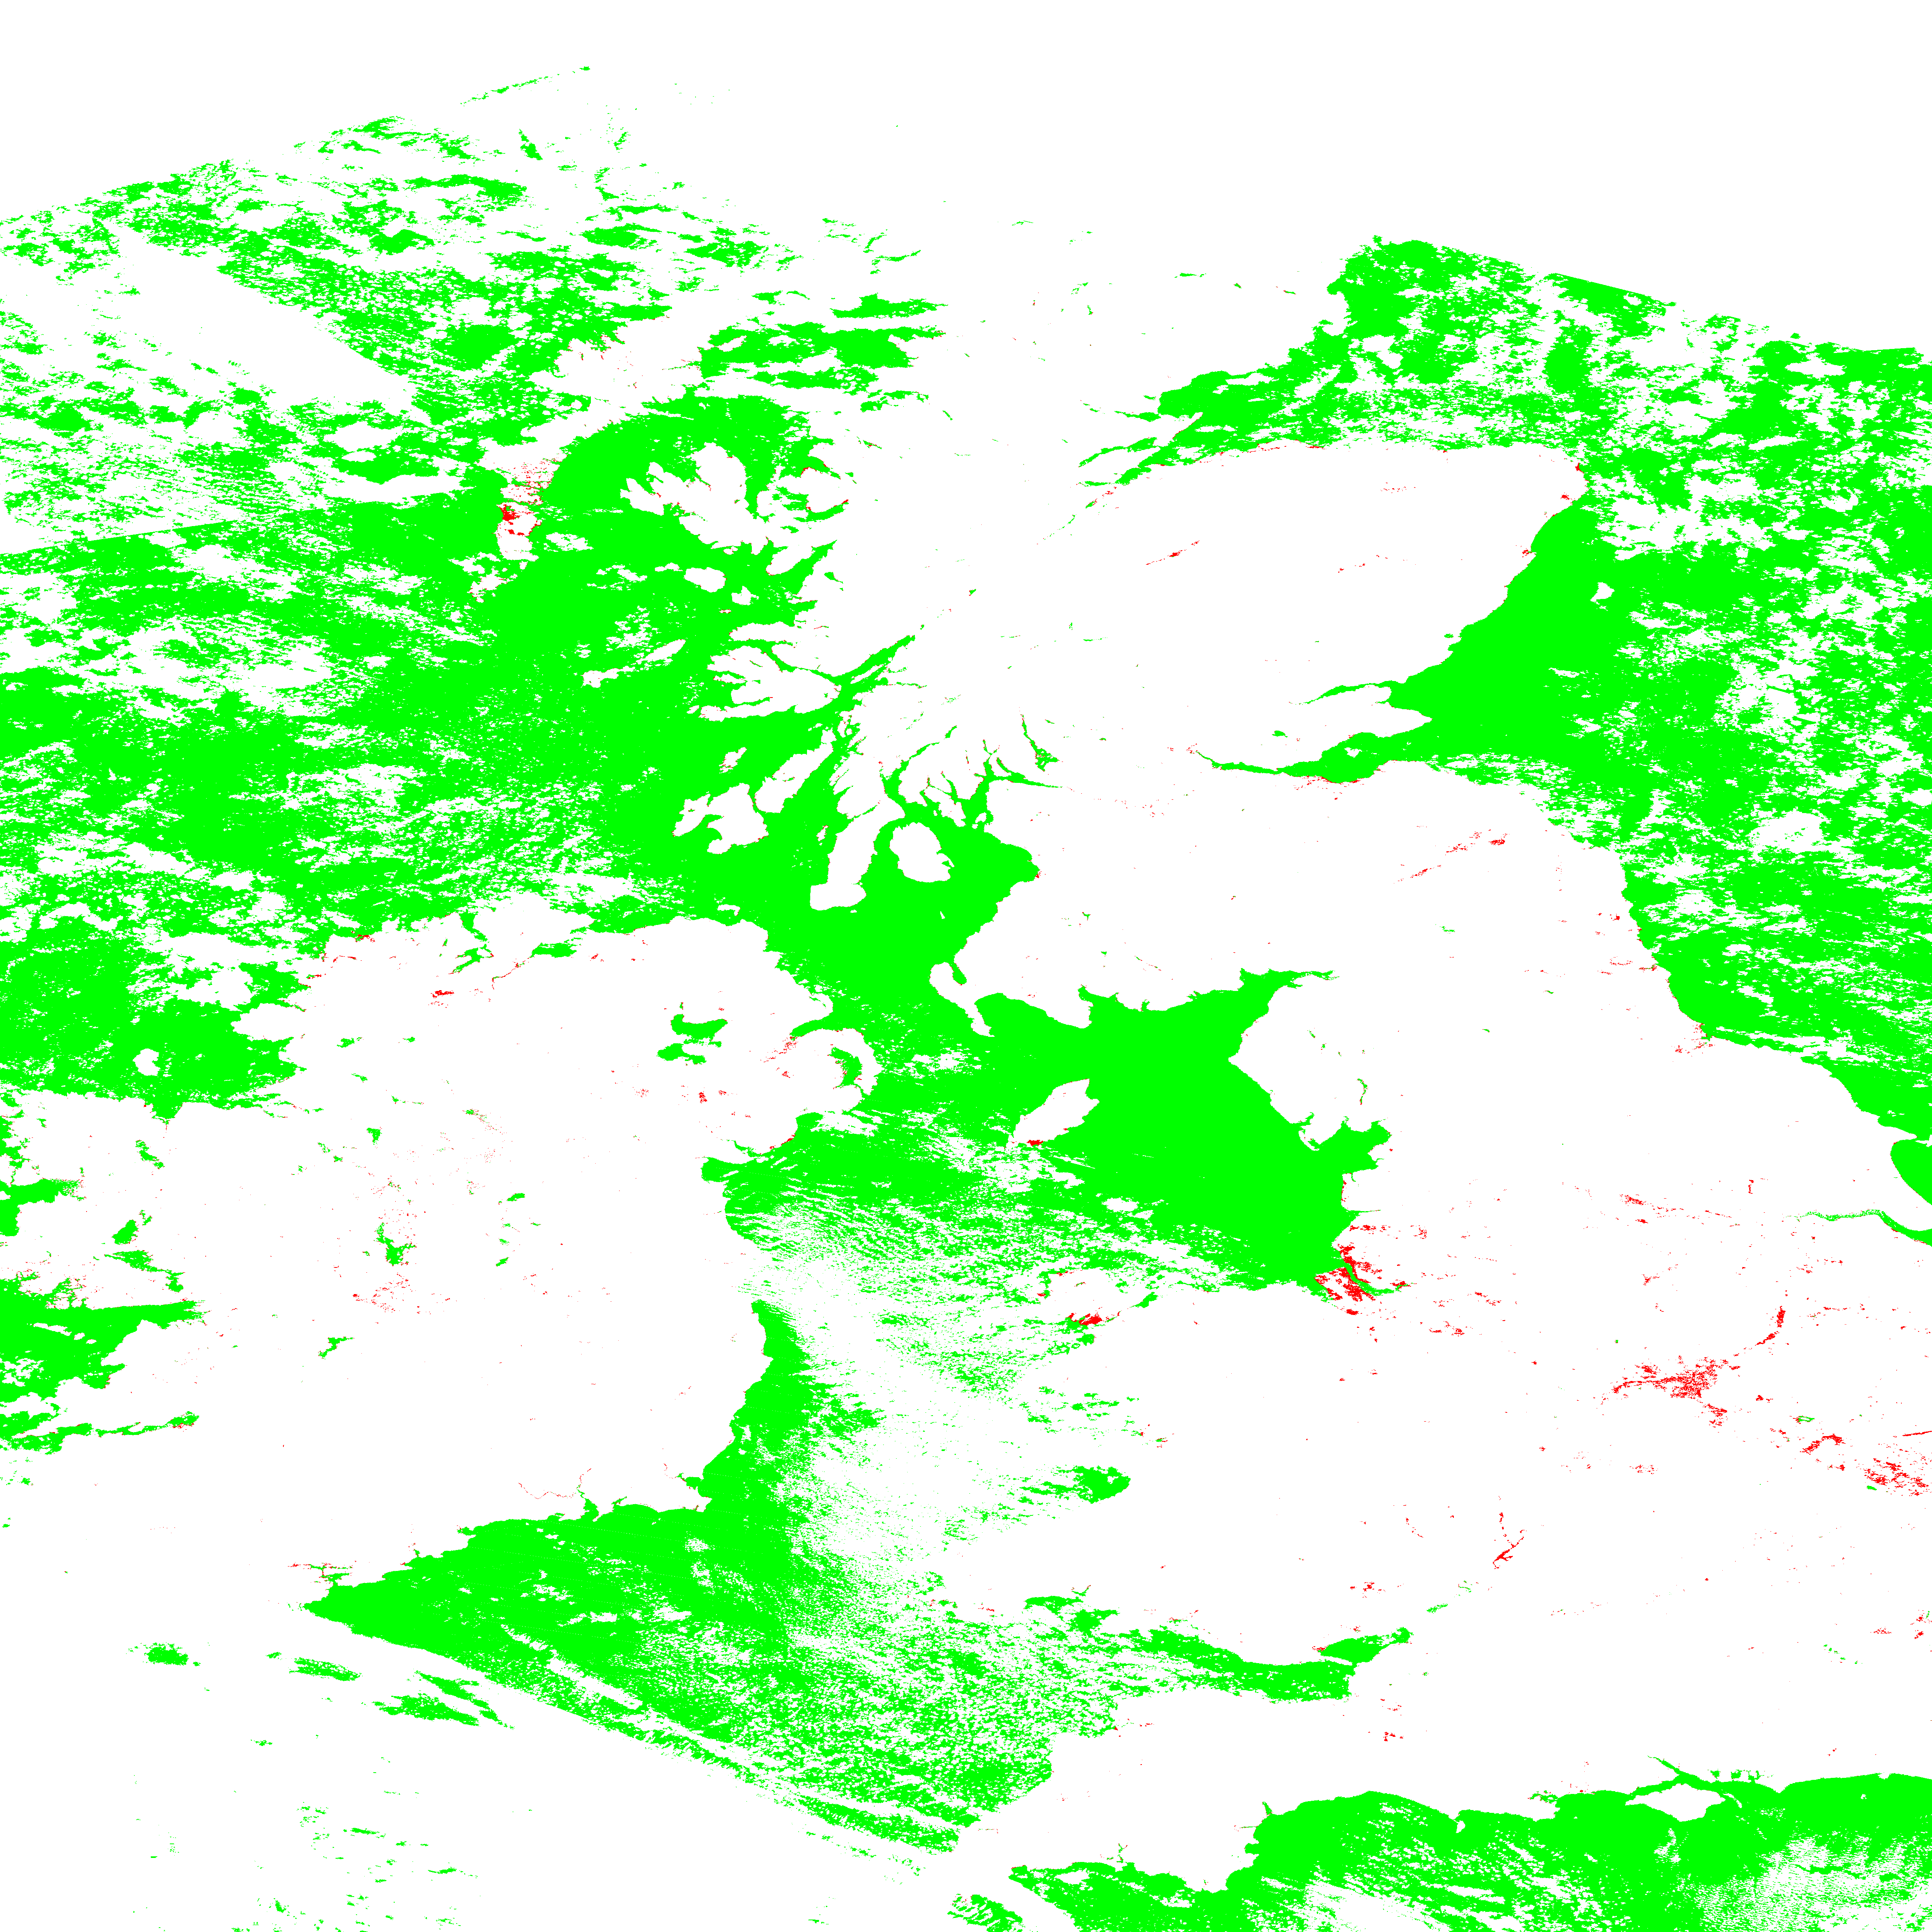

In [11]:
def colormap(value):
    color_dict = {
        1: (0, 255, 0, 255),      # Green for 1, Surface water
        2: (255, 255, 0, 255),    # Yellow for 2, Recurring flood
        3: (255, 0, 0, 255),    # Red for 3, Flood (unusual)
    }
    return color_dict.get(value, (0, 0, 0, 0))  # Default to transparent for other values

# Convert raster to an RGBA image using the colormap
rgba_raster = np.zeros((data_h17v03.shape[0], data_h17v03.shape[1], 4), dtype=np.uint8)
for value, color in [(1, colormap(1)), (2, colormap(2)), (3, colormap(3))]:
    mask = data_h17v03 == value
    rgba_raster[mask] = color


# Create a Folium map
m = folium.Map(location=center, zoom_start=10)

# Add the ndarray as an overlay
image = ImageOverlay(
    image=rgba_raster,
    bounds=bounds,
    opacity=0.7,
    interactive=True
)
image.add_to(m)
m

## Affected areas by Administrative level 3


In [ ]:
admin2 = gpd.read_file('gadm41_GBR_2.json')
rgds = admin2[admin2['NAME_1']=='England'].copy()

In [21]:
h17v03_stats = zonal_stats(rgds, 'MCDWD_L3_F2_NRT.A2025010.h17v03.061.tif', categorical=True)

In [22]:
for index, row in rgds.iterrows():
    h17v03_i = h17v03_stats[index]
    for level in [0, 1, 2, 3, 255]:
        value = h17v03_i[level] if level in h17v03_i.keys() else 0
        rgds.loc[index, f'level_{level}'] = value

In [25]:
rgds[['level_3', 'geometry']].explore(column = 'level_3')